# Car Price Prediction using Machine Learning

## μLearn Epochs '26 Bootcamp – Day 5 Assignment

### Regression Model Development & Evaluation

**Author:** Emil Tom Joseph

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("cardekho_dataset.csv")

In [4]:
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [5]:
df.shape

(15411, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [7]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [8]:
df.isnull().sum()

,0
Unnamed: 0,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0


In [9]:
df.duplicated().sum()

np.int64(0)

# Business Objective

Develop a machine learning model that predicts the selling price of used cars based on vehicle specifications.

### Target Variable

selling_price

### Numerical Features

- vehicle_age
- km_driven
- mileage
- engine
- max_power
- seats

### Categorical Features

- car_name
- brand
- model
- seller_type
- fuel_type
- transmission_type

In [10]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [11]:
X = df.drop("selling_price", axis=1)
y = df["selling_price"]

In [12]:
num_cols = X.select_dtypes(include=np.number).columns

cat_cols = X.select_dtypes(include="object").columns

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [16]:
dt = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [17]:
rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [18]:
def evaluate(name, y_true, pred):

    mae = mean_absolute_error(y_true, pred)

    mse = mean_squared_error(y_true, pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, pred)

    return [name, mae, mse, rmse, r2]

In [19]:
results = pd.DataFrame([
    evaluate("Linear Regression", y_test, lr_pred),
    evaluate("Decision Tree", y_test, dt_pred),
    evaluate("Random Forest", y_test, rf_pred)
], columns=[
    "Model",
    "MAE",
    "MSE",
    "RMSE",
    "R2 Score"
])

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,177595.010151,1.508264e+11,388363.806565,0.799641
1,Decision Tree,122754.289653,8.382300e+10,289522.016692,0.888649
2,Random Forest,98946.797697,4.585927e+10,214147.777529,0.939080


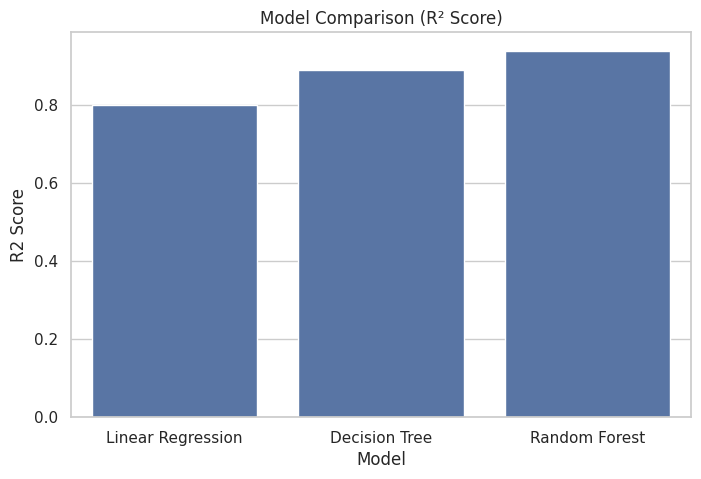

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison (R² Score)")

plt.show()

# Best Performing Model

Based on the evaluation metrics, the **Random Forest Regressor** achieved the best overall performance with the highest R² score and the lowest prediction errors.

## Why it performed better

- Captures nonlinear relationships.
- Handles complex interactions between features.
- Less prone to overfitting than a single decision tree.
- Works well with mixed numerical and categorical data.

## Strengths & Limitations

### Linear Regression
**Strengths**
- Simple and interpretable.
- Fast to train.

**Limitations**
- Cannot model nonlinear relationships.

### Decision Tree
**Strengths**
- Easy to understand.
- Handles nonlinear data.

**Limitations**
- Can overfit training data.

### Random Forest
**Strengths**
- High accuracy.
- Robust against overfitting.
- Handles feature interactions effectively.

**Limitations**
- More computationally expensive.
- Less interpretable.

## Future Improvements

- Hyperparameter tuning using GridSearchCV.
- Feature selection and additional feature engineering.
- Experiment with Gradient Boosting or XGBoost.